In [1]:
# Importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df= df[df['job_title_short'] == 'Data Analyst']

In [ ]:
df_exploded = df.explode('job_skills')

skills_stats =df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary =('salary_year_avg', 'median')
)

skills_stats = skill_stats.sort_values('skill_count', ascending = False).head(10)

C:\Users\Souradeep\AppData\Local\Temp\ipykernel_28676\3432056983.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(skills_stats['skill_count'][i], skills_stats['median_salary'][i], text)


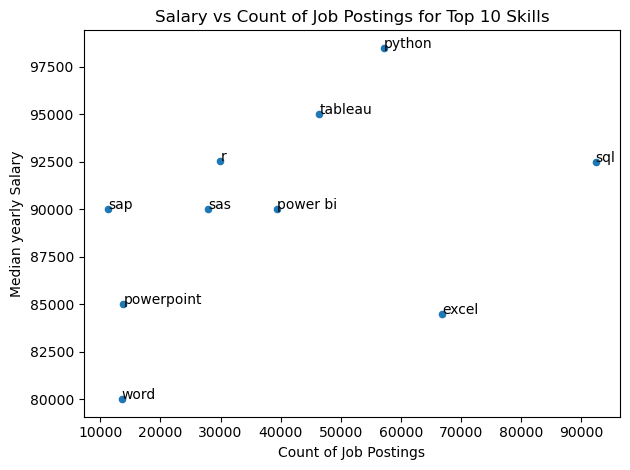

In [17]:
skills_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median yearly Salary')
plt.title('Salary vs Count of Job Postings for Top 10 Skills')
for i, text in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'][i], skills_stats['median_salary'][i], text)
plt.tight_layout()
plt.show()